In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# %pip install sncosmo
# %pip install sfdmap2
# %pip install lightcurvelynx
# %pip install nested-pandas --upgrade
# %pip install pandas --upgrade
# %pip install lsdb --upgrade

In [3]:
import matplotlib.pyplot as plt
import lsdb
import numpy as np
from lightcurvelynx.astro_utils.mag_flux import flux2mag
from astropy.cosmology import Planck18
from astropy.coordinates import Distance
import astropy.units as u
from joblib import Parallel, delayed
import pandas as pd
from nested_pandas import read_parquet
import sncosmo
import nested_pandas as npd
from utils import nightly_coadd

from dask.distributed import Client

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
client = Client(n_workers=40, memory_limit="10 GiB", threads_per_worker=1)
display(client)

/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36131 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:36131/status,
Dashboard: http://127.0.0.1:36131/status,Workers: 40
Total threads: 40,Total memory: 400.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45289,Workers: 0
Dashboard: http://127.0.0.1:36131/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37447,Total threads: 1
Dashboard: http://127.0.0.1:38765/status,Memory: 10.00 GiB
Nanny: tcp://127.0.0.1:46515,


In [5]:
import os
os.environ["SFD_DIR"] = "/astro/users/midai/sfdmap2/sfddata-master"

In [6]:
DDF = False
refit_salt = True

In [7]:
from pathlib import Path
outdir = Path('outputs/')

In [8]:
columns = ["max_reliability","max_snr","ndet","nbands","n_g","n_r","n_i","n_z","dt",
           "median_flux_diff_ratio","median_flux_diff_ratio_abs","_dist_arcsec"]
bins_map = {"median_flux_diff_ratio": np.linspace(0,5,20),
        "median_flux_diff_ratio_abs": np.linspace(0,1,20)}
if DDF:
    sncandid_filename = "sncandid_w_bazin_ddf"
else:
    sncandid_filename = "sncandid_w_bazin"
sncat_meta = lsdb.open_catalog(outdir / sncandid_filename,columns=columns)

In [9]:
len(sncat_meta)

56647

In [10]:
snmeta = sncat_meta.head(200)

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 61.67it/s]


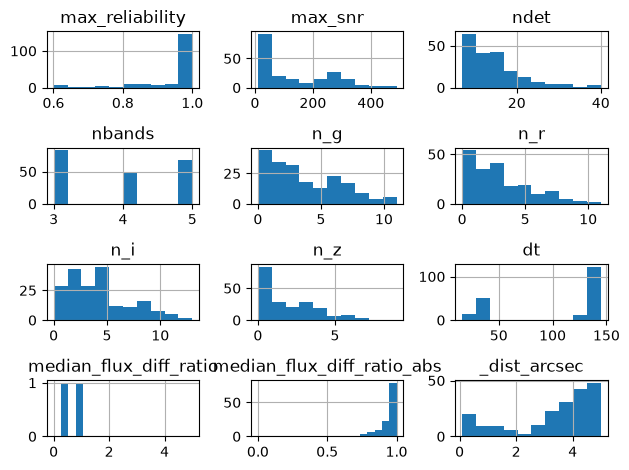

In [11]:
for i,col in enumerate(columns):
    plt.subplot(4,3,i+1)
    if col in bins_map.keys():
        bins = bins_map[col]
    else:
        bins = None
    snmeta[col].hist(bins=bins)
    plt.title(col)
plt.tight_layout()
plt.show()

In [12]:
bazin_cols = [f"bazin_fit_reduced_chi2_{b}" for b in "griz"]
sncat_bazin = lsdb.open_catalog(outdir / sncandid_filename,columns=bazin_cols)

In [13]:
snbazin = sncat_bazin.head(200)

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 63.93it/s]


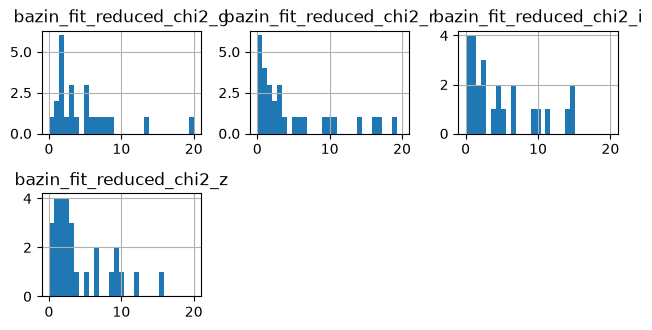

In [14]:
for i,col in enumerate(bazin_cols):
    plt.subplot(3,3,i+1)
    snbazin[col].hist(bins=np.linspace(0,20,30))
    plt.title(col)
plt.tight_layout()
plt.show()

In [15]:
sncat = lsdb.open_catalog(outdir / sncandid_filename)

In [16]:
def filter_bazin(df):
    df = df.query("((bazin_fit_reduced_chi2_r > 0.1 and bazin_fit_reduced_chi2_r < 10.0) or "
                  "(bazin_fit_reduced_chi2_g > 0.1 and bazin_fit_reduced_chi2_g < 10.0) or "
                  "(bazin_fit_reduced_chi2_i > 0.1 and bazin_fit_reduced_chi2_i < 10.0) or "
                  "(bazin_fit_reduced_chi2_z > 0.1 and bazin_fit_reduced_chi2_z < 10.0))")
    return df

In [17]:
sn_good = sncat.map_partitions(filter_bazin)

In [18]:
if DDF:
    goodsn_filename = "good_sne_ddf"
else:
    goodsn_filename = "good_sne"
print(goodsn_filename)

good_sne


In [19]:
sn_good.write_catalog(outdir / goodsn_filename,overwrite=True)

Writing Catalog: 100%|██████████| 8534/8534 [00:52<00:00, 162.26it/s]


In [20]:
sn_good = lsdb.open_catalog(outdir / goodsn_filename)

In [21]:
len(sn_good)

16346

In [22]:
head = sn_good.head()
head

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 35.75it/s]


diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1201182778953114746         765854791283769357         341.34429   
1201185435215938900         767449907777765750        341.175672   
1202035827652594487         767462346003054629        342.522992   
1202195572049268815         767462208564101132        342.994683   
1202215169120108259         767462208564101141        342.834923   

                     dec_dia_object_lc  refExtendedness_object_lc  \
_healpix_29                                                         
1201182778953114746         -17.881899                        1.0   
1201185435215938900         -17.801472                        1.0   
1202035827652594487          -16.50443                        1.0   
1202195572049268815          -16.52204                        1.0   
1202215169120108259         -16.573388                        1.0   

                     refSizeExtendedness_object_lc  objectId_object_lc  \
_healpix_29                                                              
1201182778953114746                            1.0  765854791283791234   
1201185435215938900                            1.0  767449907777787844   
1202035827652594487                            1.0  767462346003074436   
1202195572049268815                       0.966953  767462208564121986   
1202215169120108259                            1.0  767462208564120844   

                     coord_ra_object_lc  coord_dec_object_lc  _dist_arcsec  \
_healpix_29                                                                  
1201182778953114746           341.34317           -17.882335      4.145564   
1201185435215938900          341.176081           -17.800213      4.745399   
1202035827652594487          342.522985           -16.504559      0.466365   
1202195572049268815          342.993797           -16.522862      4.254695   
1202215169120108259          342.834998           -16.573754      1.344162   

                     ndet  ...  bazin_fit_reference_time_z  \
_healpix_29                ...                               
1201182778953114746    14  ...                  856.890381   
1201185435215938900     7  ...                  864.774719   
1202035827652594487    22  ...                  825.776917   
1202195572049268815    32  ...                  866.674255   
1202215169120108259    24  ...                  866.236328   

                     bazin_fit_rise_time_z  bazin_fit_fall_time_z  \
_healpix_29                                                         
1201182778953114746               2.778052               1.625902   
1201185435215938900               0.709981               2.630699   
1202035827652594487             218.887695              21.319601   
1202195572049268815               0.109278               0.190674   
1202215169120108259               0.782752               1.532918   

                     bazin_fit_reduced_chi2_z       chi2_g      chi2_r  \
_healpix_29                                                              
1201182778953114746                100.293564    21.885887  338.313416   
1201185435215938900                  3.077245   677.559265    4.644212   
1202035827652594487                  6.655687   428.384979  119.714455   
1202195572049268815                  6.674976  9287.736328  950.169922   
1202215169120108259                  3.198567  8804.480469  7171.53125   

                          chi2_i     chi2_z  \
_healpix_29                                   
1201182778953114746  248331.8125   55.72271   
1201185435215938900   100.513771   0.643571   
1202035827652594487    80.776558   1.378513   
1202195572049268815  1099.493652  64.238907   
1202215169120108259   2602.77002   1.252941   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
1201182778953114746  [{midpointMjdTai: 60858.261648, band: 'i', psf...   
1201

In [23]:
colors = {"u": "pink",
          "g": "green",
          "r": "red",
          "i": "purple",
          "z": "orange",
          "y": "brown"}
def plot_lc(lc,saltpars=None):
    maxflux = 0.
    for f in lc["band"].unique():
        lc_f = lc.loc[lc["band"]==f]
        is_det = np.absolute(lc_f["snr"]) > 5
        lc_det = lc_f.loc[is_det]
        lc_nondet = lc_f.loc[~is_det]
        plt.errorbar(lc_det["mjd"],lc_det["flux"],yerr=lc_det["fluxerr"],fmt='o',label=f, c=colors[f])
        plt.errorbar(lc_nondet["mjd"],lc_nondet["flux"],yerr=lc_nondet["fluxerr"],fmt='>',alpha=0.3, c=colors[f])

        if saltpars is not None:
            model = sncosmo.Model("salt3",effects=[sncosmo.F99Dust()], effect_names=["mw"], effect_frames=["obs"])
            model.update(saltpars)
            time = np.linspace(-20,50,100)*(1.+saltpars["z"]) + saltpars["t0"]
            try:
                flux = model.bandflux("lsst"+f,time,zp=31.4, zpsys='ab')
                maxflux = np.max(np.append(flux,maxflux))
                plt.plot(time,flux,c=colors[f],alpha=0.1,ls="--")
            except:
                continue
        plt.legend()
    is_det = np.absolute(lc["snr"]) > 5
    if saltpars:
        ylim = (-0.2*maxflux, maxflux*1.5)
    else:
        ylim = (-0.2*lc.loc[is_det]["flux"].max(),lc.loc[is_det]["flux"].max()*1.5)
    # plt.ylim(ylim)

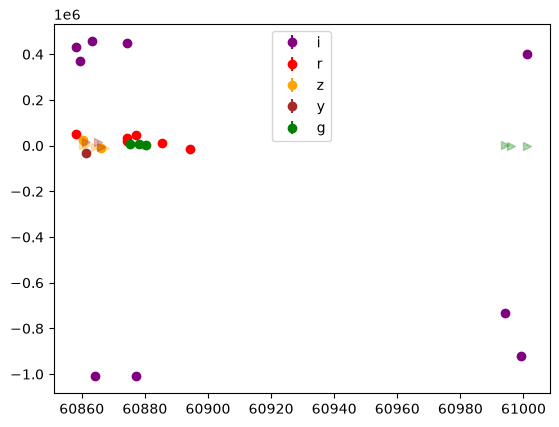

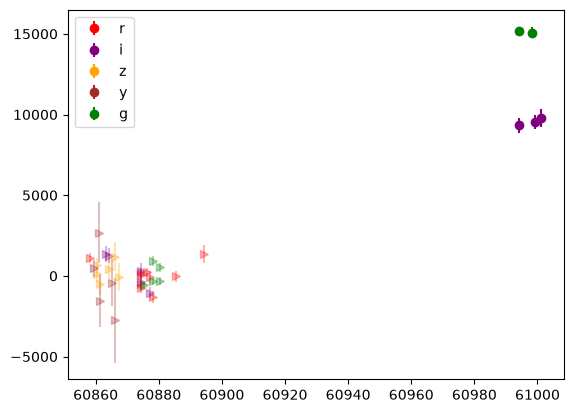

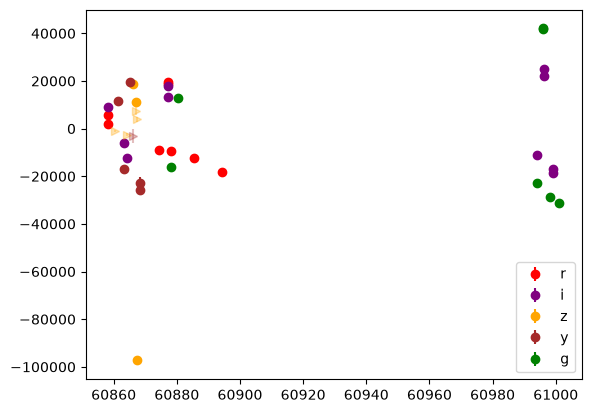

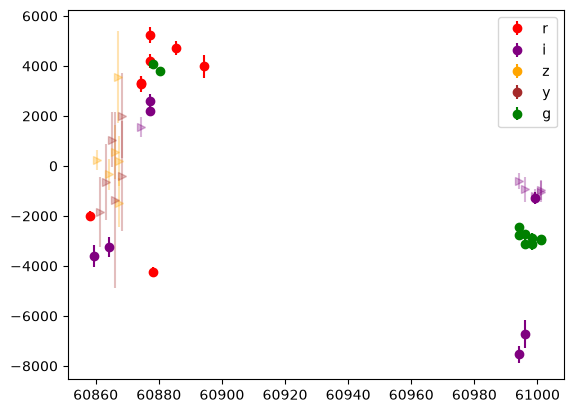

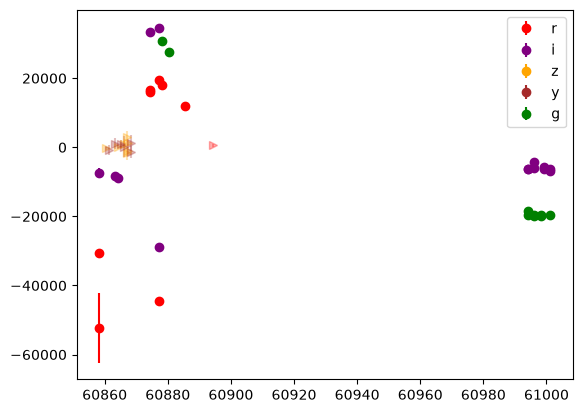

In [24]:
sn = head
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    # plt.subplot(2,1,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc)
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc)
    plt.show()

In [25]:
def lc_quality_cuts(flux,mjd,filter,snr, n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    det = snr > 5
    flux = flux[det]
    mjd = mjd[det]
    filter = filter[det]
    if len(flux) == 0:
        return False
    peak_idx = np.argmax(flux)
    phases = np.floor((mjd - mjd[peak_idx]))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -40) & (unique_phases<=100)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    flux_new = flux[unique_idx][good_idx]
    peak_idx_new = np.argmax(flux_new)
    pass_cut &= (peak_idx_new >= n_before_peak - 1) & (len(flux_new) - peak_idx_new >= n_after_peak - 1)
    good_phases = (phases >= -40) & (phases<=100)
    pass_cut &= len(np.unique(filter[good_phases])) >= n_bands
    return pass_cut

In [26]:
def make_lc_quality_cuts(df):
    df["diaObjectForcedSource_dia_object_lc.snr"] = df["diaObjectForcedSource_dia_object_lc.psfDiffFlux"]/df["diaObjectForcedSource_dia_object_lc.psfDiffFluxErr"]
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=bool) for name in ["pass_quality_cut"]}) 
    else:
        df = df.map_rows(lc_quality_cuts,columns=["diaObjectForcedSource_dia_object_lc.psfDiffFlux",
                                       "diaObjectForcedSource_dia_object_lc.midpointMjdTai",
                                       "diaObjectForcedSource_dia_object_lc.band",
                                       "diaObjectForcedSource_dia_object_lc.snr"],
                                       row_container="args",output_names=["pass_quality_cut"], 
                                       append_columns=True)
    return df

In [27]:
sn_good_after_quality_cut = sn_good.map_partitions(make_lc_quality_cuts)

In [28]:
good_qc_filename = "good_sne_after_quality_cut"

In [29]:
sn_good_after_quality_cut = sn_good_after_quality_cut.query("pass_quality_cut == True")

In [30]:
sn_good_after_quality_cut.head()

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 16.32it/s]


diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1201182778953114746         765854791283769357         341.34429   
1202035827652594487         767462346003054629        342.522992   
1202215169120108259         767462208564101141        342.834923   
1202222701112768358         769064746761584687         342.93668   
1203554616946760466         769089898090070084        348.264834   

                     dec_dia_object_lc  \
_healpix_29                              
1201182778953114746         -17.881899   
1202035827652594487          -16.50443   
1202215169120108259         -16.573388   
1202222701112768358          -16.28705   
1203554616946760466         -15.266771   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
1201182778953114746  [{midpointMjdTai: 60858.261648, band: 'i', psf...   
1202035827652594487  [{midpointMjdTai: 60858.28367, band: 'r', psfD...   
1202215169120108259  [{midpointMjdTai: 60858.28367, band: 'r', psfD...   
1202222701112768358  [{midpointMjdTai: 60858.28367, band: 'r', psfD...   
1203554616946760466  [{midpointMjdTai: 60857.302091, band: 'r', psf...   

                                               diaSource_dia_object_lc  \
_healpix_29                                                              
1201182778953114746  [{midpointMjdTai: 60858.261648, band: 'i', psf...   
1202035827652594487  [{midpointMjdTai: 60858.28367, band: 'r', psfF...   
1202215169120108259  [{midpointMjdTai: 60858.28367, band: 'r', psfF...   
1202222701112768358  [{midpointMjdTai: 60858.28367, band: 'r', psfF...   
1203554616946760466  [{midpointMjdTai: 60858.284577, band: 'r', psf...   

                     refExtendedness_object_lc  refSizeExtendedness_object_lc  \
_healpix_29                                                                     
1201182778953114746                        1.0                            1.0   
1202035827652594487                        1.0                            1.0   
1202215169120108259                        1.0                            1.0   
1202222701112768358                        1.0                            1.0   
1203554616946760466                        1.0                       0.949565   

                     objectId_object_lc  coord_ra_object_lc  \
_healpix_29                                                   
1201182778953114746  765854791283791234           341.34317   
1202035827652594487  767462346003074436          342.522985   
1202215169120108259  767462208564120844          342.834998   
1202222701112768358  769064746761608397          342.936598   
1203554616946760466  769089898090089773          348.265421   

                     coord_dec_object_lc  ...  bazin_fit_baseline_z  \
_healpix_29                               ...                         
1201182778953114746           -17.882335  ...         -10462.147461   
1202035827652594487           -16.504559  ...           -995.381287   
1202215169120108259           -16.573754  ...           -220.313629   
1202222701112768358            -16.28703  ...            111.289597   
1203554616946760466           -15.267943  ...         -25356.097656   

                     bazin_fit_reference_time_z  bazin_fit_rise_time_z  \
_healpix_29                                                              
1201182778953114746                  856.890381               2.778052   
1202035827652594487                  825.776917             218.887695   
1202215169120108259                  866.236328               0.782752   
1202222701112768358                  867.079346               0.004557   
1203554616946760466                  858.571838               4.704329   

                     bazin_fit_fall_time_z  bazin_fit_reduced_chi2_z  \
_healpix_29                                                            
1201182778953114746               1.6259

In [31]:
sn_good_after_quality_cut.write_catalog(outdir / good_qc_filename,overwrite=True)

Writing Catalog: 100%|██████████| 4528/4528 [00:39<00:00, 113.33it/s]


In [32]:
sn_good_after_quality_cut = lsdb.open_catalog(outdir / good_qc_filename)
len(sn_good_after_quality_cut)

9547

In [33]:
head = sn_good_after_quality_cut.head()

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00, 34.61it/s]


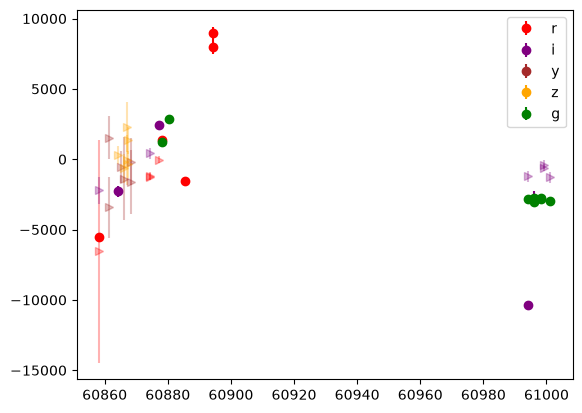

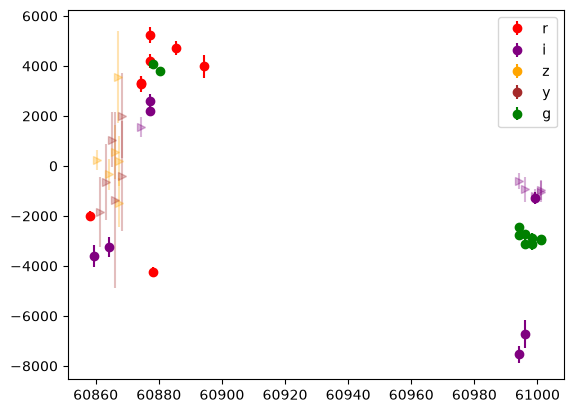

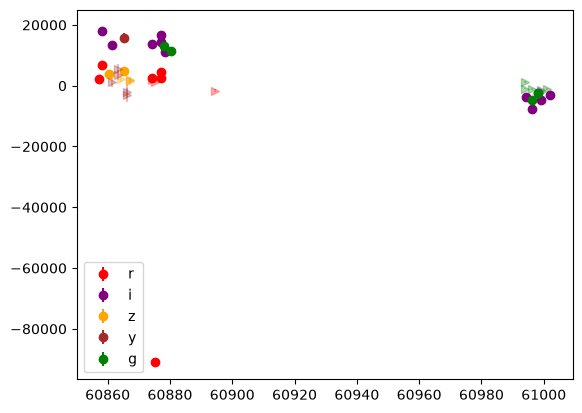

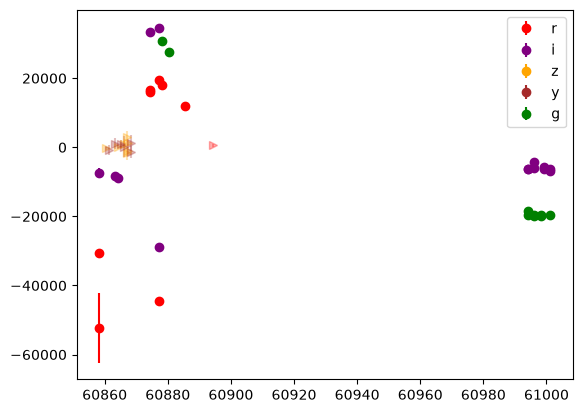

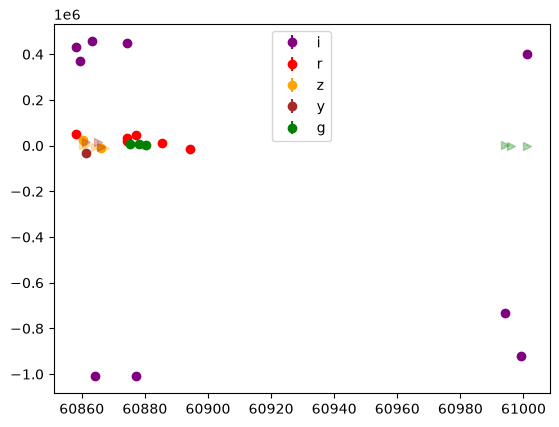

In [34]:
sn = head
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    # plt.subplot(2,1,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    plot_lc(lc)
    # plt.subplot(2,1,2)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc = lc[["midpointMjdTai","band","psfFlux","psfFluxErr"]]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc)
    plt.show()

In [35]:
from lcfit import fit_single_lc  

def fit_single_lc_w_cond(lc,
                         bounds={"x1": (-4,4),
                                 "c": (-0.4,0.8),},
                         phase_range=(-15,45),
                         modelcov=False):
    return fit_single_lc(lc,mpbounds=bounds,phase_range=phase_range,modelcov=modelcov)

In [36]:
def infer_z_from_peakmag(row):
    peakflux = np.max(row)
    peakmag = flux2mag(peakflux)
    z = Distance(distmod = peakmag + 19).compute_z(cosmology=Planck18).value
    return z

In [37]:
def compute_z_from_peakmag(df):
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=np.float32) for name in ["z_est"]}) 
    else:
        df = df.map_rows(infer_z_from_peakmag, columns=["diaSource_dia_object_lc.psfFlux"], row_container="args",
                         output_names=["z_est"], append_columns=True)
    return df

In [38]:
def fit_salt2(df):
    saltcolumns = ['success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err', 'x0',
           'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err', 'z_z_cov',
           'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
           't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
           't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
           'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
           'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
           'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
           'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
           'mwebv_mwebv_cov', 'id', 'fit_error']
    dtypes = [np.float64]*(len(saltcolumns)-2)+ [int] + [str]
    if len(df) == 0:
        df = df.assign(**{name: np.array([], dtype=dtype) for name,dtype in zip(saltcolumns,dtypes)}) 
    else:
        df = df.map_rows(fit_single_lc_w_cond, 
                         columns=["ra_dia_object_lc","dec_dia_object_lc","diaObjectId_dia_object_lc", "z_est",
                                  "diaSource_dia_object_lc.midpointMjdTai", "diaSource_dia_object_lc.band",
                                  "diaSource_dia_object_lc.psfFlux","diaSource_dia_object_lc.psfFluxErr"], 
                         append_columns=True)
    return df

In [39]:
sn_good_after_quality_cut = lsdb.open_catalog(outdir / good_qc_filename)
sn_good_after_quality_cut = sn_good_after_quality_cut.map_partitions(compute_z_from_peakmag)

In [40]:
# # for debugging
# sn_good_after_quality_cut = sn_good_after_quality_cut.partitions[0:100]

In [41]:
res = sn_good_after_quality_cut.map_partitions(fit_salt2,compute_single_partition=False)

In [42]:
head = res.head()

Computing Catalog: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]


In [43]:
head

diaObjectId_dia_object_lc  ra_dia_object_lc  \
_healpix_29                                                        
1201182778953114746         765854791283769357         341.34429   
1202035827652594487         767462346003054629        342.522992   
1202215169120108259         767462208564101141        342.834923   
1202222701112768358         769064746761584687         342.93668   
1203554616946760466         769089898090070084        348.264834   

                     dec_dia_object_lc  \
_healpix_29                              
1201182778953114746         -17.881899   
1202035827652594487          -16.50443   
1202215169120108259         -16.573388   
1202222701112768358          -16.28705   
1203554616946760466         -15.266771   

                                   diaObjectForcedSource_dia_object_lc  \
_healpix_29                                                              
1201182778953114746  [{midpointMjdTai: 60858.261648, band: 'i', psf...   
1202035827652594487  [{midpointMjdTai: 60858.28367, band: 'r', psfD...   
1202215169120108259  [{midpointMjdTai: 60858.28367, band: 'r', psfD...   
1202222701112768358  [{midpointMjdTai: 60858.28367, band: 'r', psfD...   
1203554616946760466  [{midpointMjdTai: 60857.302091, band: 'r', psf...   

                                               diaSource_dia_object_lc  \
_healpix_29                                                              
1201182778953114746  [{midpointMjdTai: 60858.261648, band: 'i', psf...   
1202035827652594487  [{midpointMjdTai: 60858.28367, band: 'r', psfF...   
1202215169120108259  [{midpointMjdTai: 60858.28367, band: 'r', psfF...   
1202222701112768358  [{midpointMjdTai: 60858.28367, band: 'r', psfF...   
1203554616946760466  [{midpointMjdTai: 60858.284577, band: 'r', psf...   

                     refExtendedness_object_lc  refSizeExtendedness_object_lc  \
_healpix_29                                                                     
1201182778953114746                        1.0                            1.0   
1202035827652594487                        1.0                            1.0   
1202215169120108259                        1.0                            1.0   
1202222701112768358                        1.0                            1.0   
1203554616946760466                        1.0                       0.949565   

                     objectId_object_lc  coord_ra_object_lc  \
_healpix_29                                                   
1201182778953114746  765854791283791234           341.34317   
1202035827652594487  767462346003074436          342.522985   
1202215169120108259  767462208564120844          342.834998   
1202222701112768358  769064746761608397          342.936598   
1203554616946760466  769089898090089773          348.265421   

                     coord_dec_object_lc  ...       c_c_cov  c_mwebv_cov  \
_healpix_29                               ...                              
1201182778953114746           -17.882335  ...  3.773178e-05          0.0   
1202035827652594487           -16.504559  ...  1.411873e-03          0.0   
1202215169120108259           -16.573754  ...  6.254712e-05          0.0   
1202222701112768358            -16.28703  ...  1.010005e-02          0.0   
1203554616946760466           -15.267943  ...  1.930043e-20          0.0   

                     mwebv_z_cov  mwebv_t0_cov  mwebv_x0_cov  mwebv_x1_cov  \
_healpix_29                                                                  
1201182778953114746          0.0           0.0           0.0           0.0   
1202035827652594487          0.0           0.0           0.0           0.0   
1202215169120108259          0.0           0.0           0.0           0.0   
1202222701112768358          0.0           0.0           0.0           0.0   
1203554616946760466          0.0           0.0           0.0           0.0   

                     mwebv_c_cov  mwebv_mwebv_cov                  id  \
_healpix_29                                     

In [106]:
saltres_file = "saltfit_on_good_sne_after_quality_cut"

In [ ]:
if refit_salt:
    res.write_catalog(outdir / saltres_file,overwrite=True)

Writing Catalog:   0%|          | 8/3546 [00:03<17:12,  3.43it/s]/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_u(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
Writing Catalog:   0%|          | 10/3546 [00:04<13:52,  4.25it/s]/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_u(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo/fitting.py:191: RuntimeWarning: Dropping following bands from data: lynx_lsst_u(out of model wavelength range)
  warnings.warn("Dropping following bands from data: " +
Writing Catalog:   0%|          | 14/3546 [00:04<08:03,  7.31it/s]/astro/users/midai/.conda/envs/lf_env/lib/python3.11/site-packages/sncosmo

In [107]:
columns = ['diaObjectId_dia_object_lc','success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err', 'x0',
           'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err', 'z_z_cov',
           'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
           't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
           't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
           'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
           'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
           'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
           'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
           'mwebv_mwebv_cov', 'id', 'fit_error', 'diaSource_dia_object_lc',
           'diaObjectForcedSource_dia_object_lc','_dist_arcsec']
# saltres = lsdb.open_catalog(outdir / saltres_file, columns=columns+bazin_cols)
saltres = lsdb.open_catalog(outdir / saltres_file)
len(saltres)

9547

In [108]:
saltres.columns

Index(['diaObjectId_dia_object_lc', 'ra_dia_object_lc', 'dec_dia_object_lc',
       'diaObjectForcedSource_dia_object_lc', 'diaSource_dia_object_lc',
       'refExtendedness_object_lc', 'refSizeExtendedness_object_lc',
       'objectId_object_lc', 'coord_ra_object_lc', 'coord_dec_object_lc',
       ...
       'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov', 'mwebv_t0_cov', 'mwebv_x0_cov',
       'mwebv_x1_cov', 'mwebv_c_cov', 'mwebv_mwebv_cov', 'id', 'fit_error'],
      dtype='object', length=106)

In [109]:
saltres = saltres.query("success == 1 and "
                        "(x1 > -3.99 and x1 < 3.99) and " 
                        "(c > -0.399 and c < 0.799) and "
                        "mwebv < 0.25")

In [110]:
saltres_after_cut = "saltfit_on_good_sne_after_quality_cut_and_saltpar_cut"

In [111]:
saltres.write_catalog(outdir / saltres_after_cut,overwrite=True)

Writing Catalog: 100%|██████████| 3546/3546 [00:34<00:00, 103.90it/s]


In [112]:
saltres = lsdb.open_catalog(outdir / saltres_after_cut)

(<Figure size 1000x500 with 2 Axes>,
 <WCSAxes: title={'center': 'Catalog pixel map - dia_object_lc_x_object_lc'}>)

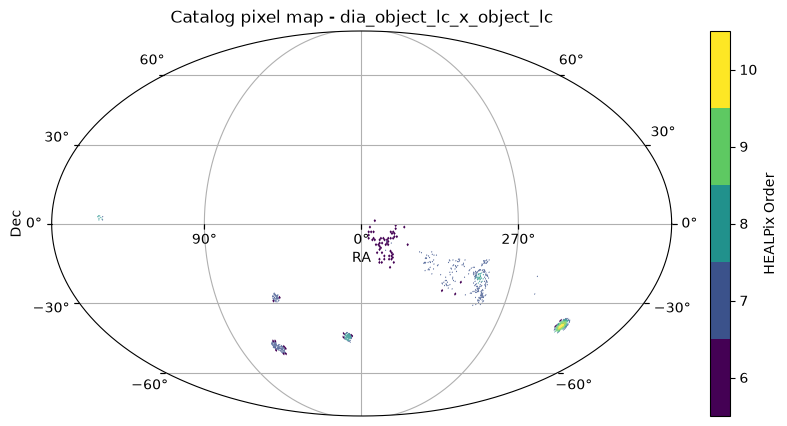

In [113]:
saltres.plot_pixels()

In [114]:
result_good = saltres.compute()

Computing Catalog: 100%|██████████| 1172/1172 [00:18<00:00, 62.09it/s] 


In [115]:
if DDF:
    res_filename = "saltfit_good_sne_ddf.parquet"
else:
    res_filename = "saltfit_good_sne.parquet"

In [116]:
result_good.to_parquet(outdir / res_filename)

In [117]:
result_good = npd.read_parquet(outdir / res_filename)

In [118]:
result_good

diaObjectId_dia_object_lc  ra_dia_object_lc  dec_dia_object_lc  \
0            769064746761584687         342.93668          -16.28705   
1            770715182434353208         349.81541         -14.502605   
...                         ...               ...                ...   
1621         773853051181072448        319.430246         -10.586335   
1622         770534450210537751        308.531661         -13.421625   

                    diaObjectForcedSource_dia_object_lc  \
0     [{midpointMjdTai: 60858.28367, band: 'r', psfD...   
1     [{midpointMjdTai: 60857.302091, band: 'r', psf...   
...                                                 ...   
1621  [{midpointMjdTai: 60831.299006, band: 'i', psf...   
1622  [{midpointMjdTai: 60847.286221, band: 'i', psf...   

                                diaSource_dia_object_lc  \
0     [{midpointMjdTai: 60858.28367, band: 'r', psfF...   
1     [{midpointMjdTai: 60858.309756, band: 'i', psf...   
...                                                 ...   
1621  [{midpointMjdTai: 60831.299006, band: 'i', psf...   
1622  [{midpointMjdTai: 60847.286221, band: 'i', psf...   

      refExtendedness_object_lc  refSizeExtendedness_object_lc  \
0                           1.0                            1.0   
1                           1.0                            1.0   
...                         ...                            ...   
1621                        1.0                            1.0   
1622                        1.0                            1.0   

      objectId_object_lc  coord_ra_object_lc  coord_dec_object_lc  ...  \
0     769064746761608397          342.936598            -16.28703  ...   
1     770715182434378708          349.814679           -14.503023  ...   
...                  ...                 ...                  ...  ...   
1621  773853051181091625          319.430534           -10.586525  ...   
1622  770534450210558277          308.531721           -13.421645  ...   

      c_mwebv_cov  mwebv_z_cov  mwebv_t0_cov  mwebv_x0_cov  mwebv_x1_cov  \
0             0.0          0.0           0.0           0.0           0.0   
1             0.0          0.0           0.0           0.0           0.0   
...           ...          ...           ...           ...           ...   
1621          0.0          0.0           0.0           0.0           0.0   
1622          0.0          0.0           0.0           0.0           0.0   

      mwebv_c_cov  mwebv_mwebv_cov                  id  fit_error  \
0             0.0              0.0  769064746761584687       None   
1             0.0              0.0  770715182434353208       None   
...           ...              ...                 ...        ...   
1621          0.0              0.0  773853051181072448       None   
1622          0.0              0.0  770534450210537751       None   

              _healpix_29  
0     1202222701112768358  
1     1204312627520364251  
...                   ...  
1621  3447791726003754834  
1622  3449914035933787781  

[1623 rows x 107 columns]

<Axes: >

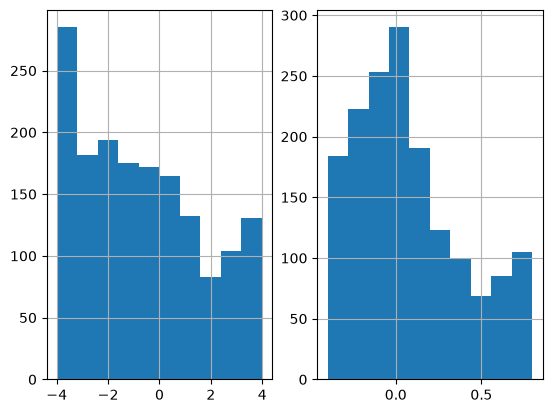

In [119]:
plt.subplot(1,2,1)
result_good.x1.hist()
plt.subplot(1,2,2)
result_good.c.hist()

In [120]:
result_good["reduced_chisq"] = result_good.chisq / result_good.ndof

<Axes: >

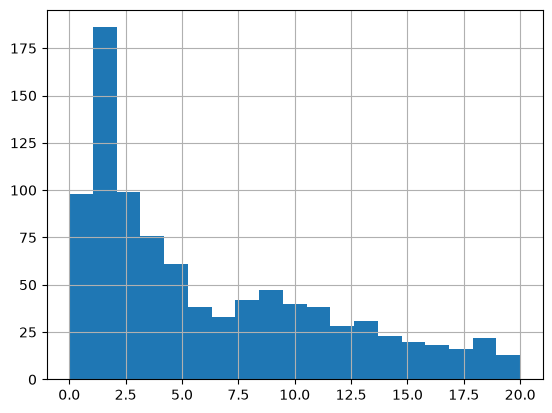

In [121]:
result_good.reduced_chisq.hist(bins = np.linspace(0, 20, 20))

In [122]:
sn_good

diaObjectId_dia_object_lc  success  ncall      chisq  ndof         z  \
1            770715182434353208      1.0   66.0   5.853364   2.0  0.200938   
2            770709684876214277      1.0  669.0   0.320971   2.0  0.471247   
...                         ...      ...    ...        ...   ...       ...   
1616         772222200559174513      1.0  175.0  24.958283   6.0  0.351558   
1620         773841506308980910      1.0   64.0   4.906907   4.0  0.475209   

         z_err            t0    t0_err        x0  ...  _dist_arcsec  \
1     0.048221  60886.837128  2.973748  0.000021  ...      2.959916   
2     0.343295  60886.087799  2.914222   0.00001  ...      0.363458   
...        ...           ...       ...       ...  ...           ...   
1616  0.011352  60890.801538  0.373523  0.000026  ...      2.754973   
1620  0.055125  60874.678444  2.107529   0.00001  ...      0.444557   

      bazin_fit_reduced_chi2_g  bazin_fit_reduced_chi2_r  \
1                    43.048645                 16.263695   
2                       0.7499                  1.827909   
...                        ...                       ...   
1616                  1.235924                  8.671637   
1620                  3.012689                  1.389447   

      bazin_fit_reduced_chi2_i  bazin_fit_reduced_chi2_z  ra_dia_object_lc  \
1                     6.494649                    1.2824         349.81541   
2                     0.522935                  1.306515        348.175327   
...                        ...                       ...               ...   
1616                  1.241318                  1.645698        322.437258   
1620                  0.677094                  0.950165        317.573461   

      dec_dia_object_lc          _healpix_29  reduced_chisq  pass_quality_cuts  
1            -14.502605  1204312627520364251       2.926682              False  
2            -14.132379  1205125033720795550       0.160486              False  
...                 ...                  ...            ...                ...  
1616         -12.530215  3445566514577177571       4.159714               True  
1620         -11.751008  3447516632268407806       1.226727               True  

[500 rows x 67 columns]

In [123]:
sn_good = result_good.loc[(result_good.reduced_chisq > 0.1) & (result_good.reduced_chisq < 5.)]
# sn_good = sn_good.query("((bazin_fit_reduced_chi2_r > 0.1 and bazin_fit_reduced_chi2_r < 10.0) or "
#                   "(bazin_fit_reduced_chi2_g > 0.1 and bazin_fit_reduced_chi2_g < 10.0) or "
#                   "(bazin_fit_reduced_chi2_i > 0.1 and bazin_fit_reduced_chi2_i < 10.0) or "
#                   "(bazin_fit_reduced_chi2_z > 0.1 and bazin_fit_reduced_chi2_z < 10.0))")
# sn_good = sn_good.loc[(sn_good.x1 > -3.) & (sn_good.x1 < 3.) & (sn_good.c > -0.2) & (sn_good.c < 0.5)]

In [124]:
sn_good

diaObjectId_dia_object_lc  ra_dia_object_lc  dec_dia_object_lc  \
1            770715182434353208         349.81541         -14.502605   
2            770709684876214277        348.175327         -14.132379   
...                         ...               ...                ...   
1616         772222200559174513        322.437258         -12.530215   
1620         773841506308980910        317.573461         -11.751008   

                    diaObjectForcedSource_dia_object_lc  \
1     [{midpointMjdTai: 60857.302091, band: 'r', psf...   
2     [{midpointMjdTai: 60857.302091, band: 'r', psf...   
...                                                 ...   
1616  [{midpointMjdTai: 60831.302051, band: 'i', psf...   
1620  [{midpointMjdTai: 60831.299006, band: 'i', psf...   

                                diaSource_dia_object_lc  \
1     [{midpointMjdTai: 60858.309756, band: 'i', psf...   
2     [{midpointMjdTai: 60857.302091, band: 'r', psf...   
...                                                 ...   
1616  [{midpointMjdTai: 60880.243174, band: 'g', psf...   
1620  [{midpointMjdTai: 60831.329027, band: 'g', psf...   

      refExtendedness_object_lc  refSizeExtendedness_object_lc  \
1                           1.0                            1.0   
2                           1.0                       0.980221   
...                         ...                            ...   
1616                        1.0                       0.999992   
1620                        1.0                       0.995698   

      objectId_object_lc  coord_ra_object_lc  coord_dec_object_lc  ...  \
1     770715182434378708          349.814679           -14.503023  ...   
2     770709684876238987          348.175416           -14.132328  ...   
...                  ...                 ...                  ...  ...   
1616  772222200559197125          322.437964           -12.529882  ...   
1620  773841506309001168          317.573587           -11.751001  ...   

      mwebv_z_cov  mwebv_t0_cov  mwebv_x0_cov  mwebv_x1_cov  mwebv_c_cov  \
1             0.0           0.0           0.0           0.0          0.0   
2             0.0           0.0           0.0           0.0          0.0   
...           ...           ...           ...           ...          ...   
1616          0.0           0.0           0.0           0.0          0.0   
1620          0.0           0.0           0.0           0.0          0.0   

      mwebv_mwebv_cov                  id  fit_error          _healpix_29  \
1                 0.0  770715182434353208       None  1204312627520364251   
2                 0.0  770709684876214277       None  1205125033720795550   
...               ...                 ...        ...                  ...   
1616              0.0  772222200559174513       None  3445566514577177571   
1620              0.0  773841506308980910       None  3447516632268407806   

      reduced_chisq  
1          2.926682  
2          0.160486  
...             ...  
1616       4.159714  
1620       1.226727  

[500 rows x 108 columns]

<Axes: >

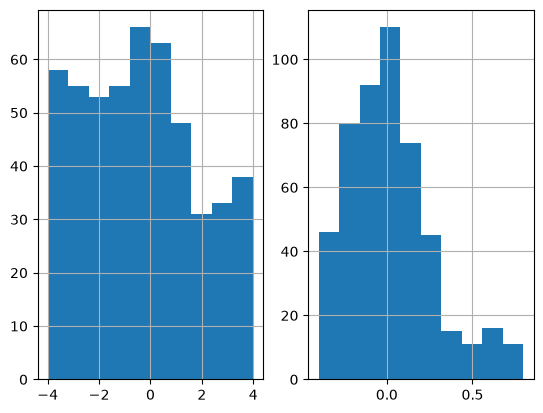

In [125]:
plt.subplot(1,2,1)
sn_good.x1.hist()
plt.subplot(1,2,2)
sn_good.c.hist()

In [126]:
# define quality cuts for lightcurves
def lc_quality_cuts(flux,mjd,filter,z,t0,n_phases=5, n_before_peak=1, n_after_peak=2, n_bands=3):
    phases = np.floor((mjd - t0)/(1. + z))
    unique_phases,unique_idx = np.unique(phases,return_index=True)
    good_idx = (unique_phases >= -10) & (unique_phases<=40)
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    if np.sum(good_idx) == 0:
        return {"pass_quality_cuts": False}
    pass_before = np.sum(unique_phases[good_idx] < 0) >= n_before_peak
    pass_after = np.sum(unique_phases[good_idx] > 0) >= n_after_peak
    pass_cut = len(unique_phases[good_idx]) >= n_phases
    pass_cut &= pass_before
    pass_cut &= pass_after
    pass_cut &= len(np.unique(filter[(phases >=-10) & (phases <=40)])) >= n_bands
    return {"pass_quality_cuts": pass_cut}

In [127]:
sn = sn_good

In [128]:
sn["diaObjectForcedSource_dia_object_lc.snr"] = sn["diaObjectForcedSource_dia_object_lc.psfDiffFlux"]/sn["diaObjectForcedSource_dia_object_lc.psfDiffFluxErr"]
sn_det = sn.query("diaObjectForcedSource_dia_object_lc.snr > 5")
pass_quality_cut = sn_det.map_rows(lc_quality_cuts,columns=["diaObjectForcedSource_dia_object_lc.psfDiffFlux",
                               "diaObjectForcedSource_dia_object_lc.midpointMjdTai",
                               "diaObjectForcedSource_dia_object_lc.band","z","t0"],
                               row_container="args")
idx = pass_quality_cut.query("pass_quality_cuts == True").index
sn["pass_quality_cuts"] = False
sn.loc[idx,"pass_quality_cuts"] = True
sn = sn[sn["pass_quality_cuts"] == True]

In [129]:
sn

diaObjectId_dia_object_lc  ra_dia_object_lc  dec_dia_object_lc  \
3            772330914771370002        346.395263         -12.876365   
16           770681303732322439         340.94076         -14.501356   
...                         ...               ...                ...   
1616         772222200559174513        322.437258         -12.530215   
1620         773841506308980910        317.573461         -11.751008   

                    diaObjectForcedSource_dia_object_lc  \
3     [{midpointMjdTai: 60857.302557, band: 'r', psf...   
16    [{midpointMjdTai: 60857.340952, band: 'r', psf...   
...                                                 ...   
1616  [{midpointMjdTai: 60831.302051, band: 'i', psf...   
1620  [{midpointMjdTai: 60831.299006, band: 'i', psf...   

                                diaSource_dia_object_lc  \
3     [{midpointMjdTai: 60857.302557, band: 'r', psf...   
16    [{midpointMjdTai: 60863.263417, band: 'i', psf...   
...                                                 ...   
1616  [{midpointMjdTai: 60880.243174, band: 'g', psf...   
1620  [{midpointMjdTai: 60831.329027, band: 'g', psf...   

      refExtendedness_object_lc  refSizeExtendedness_object_lc  \
3                           1.0                            1.0   
16                          1.0                            1.0   
...                         ...                            ...   
1616                        1.0                       0.999992   
1620                        1.0                       0.995698   

      objectId_object_lc  coord_ra_object_lc  coord_dec_object_lc  ...  \
3     772330914771390648           346.39426           -12.876543  ...   
16    770681303732345191          340.941008           -14.501467  ...   
...                  ...                 ...                  ...  ...   
1616  772222200559197125          322.437964           -12.529882  ...   
1620  773841506309001168          317.573587           -11.751001  ...   

      mwebv_t0_cov  mwebv_x0_cov  mwebv_x1_cov  mwebv_c_cov  mwebv_mwebv_cov  \
3              0.0           0.0           0.0          0.0              0.0   
16             0.0           0.0           0.0          0.0              0.0   
...            ...           ...           ...          ...              ...   
1616           0.0           0.0           0.0          0.0              0.0   
1620           0.0           0.0           0.0          0.0              0.0   

                      id  fit_error          _healpix_29  reduced_chisq  \
3     772330914771370002       None  1205693261461293803       0.422049   
16    770681303732322439       None  1298625712054983341       2.933457   
...                  ...        ...                  ...            ...   
1616  772222200559174513       None  3445566514577177571       4.159714   
1620  773841506308980910       None  3447516632268407806       1.226727   

      pass_quality_cuts  
3                  True  
16                 True  
...                 ...  
1616               True  
1620               True  

[276 rows x 109 columns]

{'x0': 2.539099861337663e-05, 'x1': -1.0155440529208217, 'c': -0.23531844165892962, 'z': 0.4711823194297073, 'mwebv': 0.0889416495249648, 't0': 60858.32349732582}
dist,reduced_chi2= 2.4017499622037155 2.4393459433145956


/local/tmp/ipykernel_1732486/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


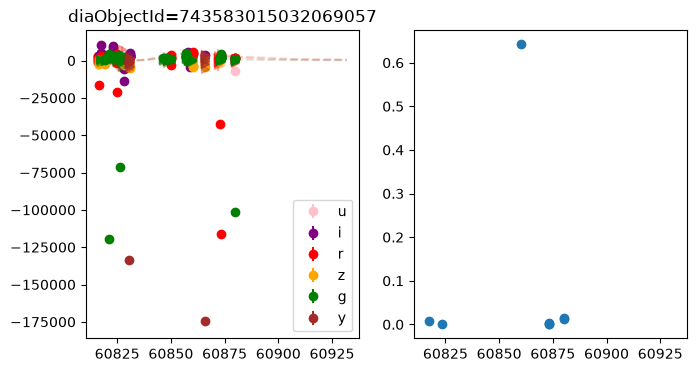

{'x0': 1.4332286385840867e-05, 'x1': 0.08795324608417908, 'c': 0.29321924799027094, 'z': 0.16079601044455333, 'mwebv': 0.007327346074227114, 't0': 60882.33951811838}
dist,reduced_chi2= 2.683320653941321 3.466205259217416


/local/tmp/ipykernel_1732486/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


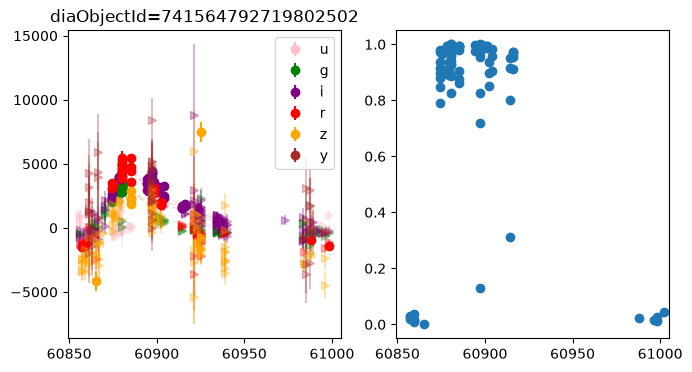

{'x0': 2.30021454911892e-05, 'x1': -3.23068593242373, 'c': 0.1303719578617723, 'z': 0.08638840475588014, 'mwebv': 0.031040304265361432, 't0': 60904.13058622133}
dist,reduced_chi2= 1.4534110399498739 4.4843530895848485


/local/tmp/ipykernel_1732486/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


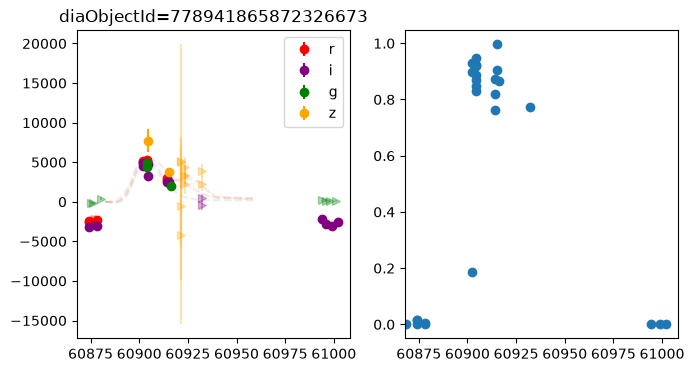

{'x0': 8.858982568911561e-06, 'x1': -0.670199333803324, 'c': 0.7976937060410295, 'z': 0.27535072575386077, 'mwebv': 0.07258535731719455, 't0': 60854.48577672904}
dist,reduced_chi2= 3.614318871431392 3.0990152773230033


/local/tmp/ipykernel_1732486/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


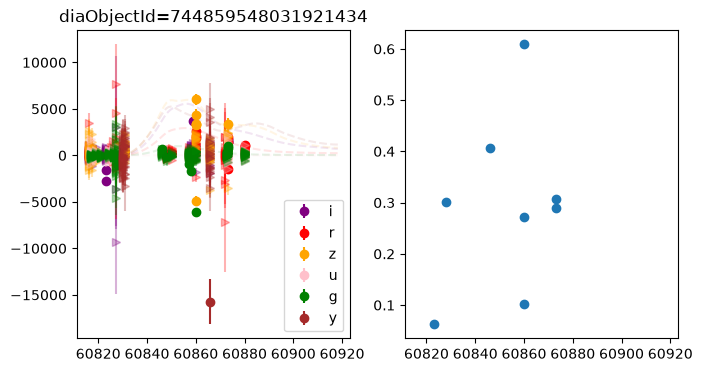

{'x0': 2.6527653889287923e-05, 'x1': -1.9105186648411683, 'c': 0.04828680419829792, 'z': 0.43240045558202944, 'mwebv': 0.008257492789135084, 't0': 60991.62106731162}
dist,reduced_chi2= 0.19481873718217405 4.8413822983963355


/local/tmp/ipykernel_1732486/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


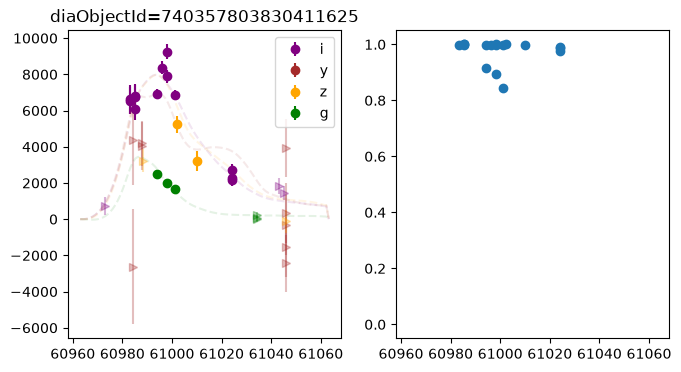

{'x0': 3.544218359338733e-05, 'x1': -0.3856089639069902, 'c': 0.13322017123508792, 'z': 0.3518403878789747, 'mwebv': 0.07774683316153347, 't0': 60911.074414288676}
dist,reduced_chi2= 0.18407171958283586 1.1332452599974054


/local/tmp/ipykernel_1732486/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


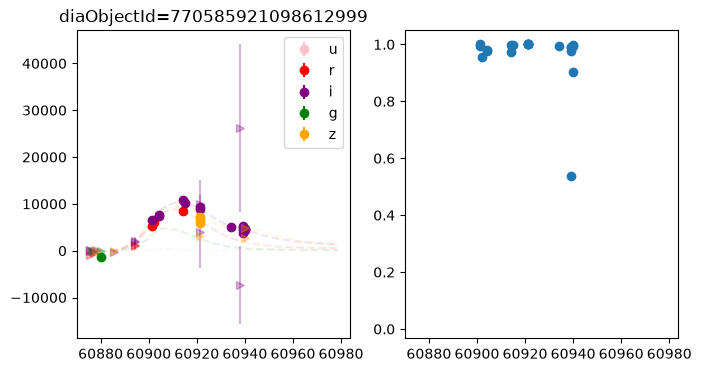

{'x0': 4.451705799312145e-05, 'x1': -2.4228415124791494, 'c': -0.19410610980594628, 'z': 0.6665736673854584, 'mwebv': 0.032176951797865117, 't0': 60867.469654505985}
dist,reduced_chi2= 3.3935815118660195 4.563784073501314


/local/tmp/ipykernel_1732486/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


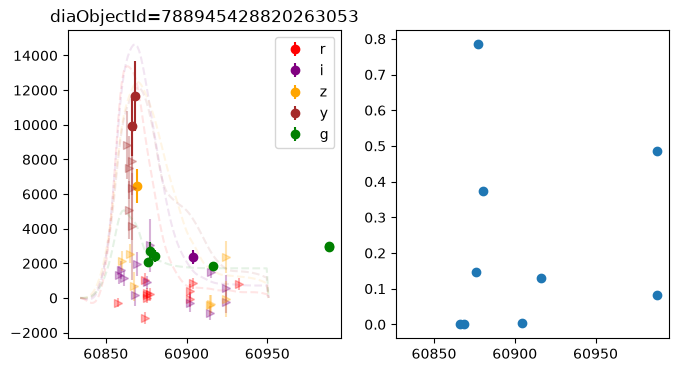

{'x0': 4.2713435526770385e-05, 'x1': -1.3668892072671328, 'c': -0.10666141388073183, 'z': 0.6812594409333945, 'mwebv': 0.0756753408260721, 't0': 60845.01653677998}
dist,reduced_chi2= 4.998068901229459 4.310844145989399


/local/tmp/ipykernel_1732486/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


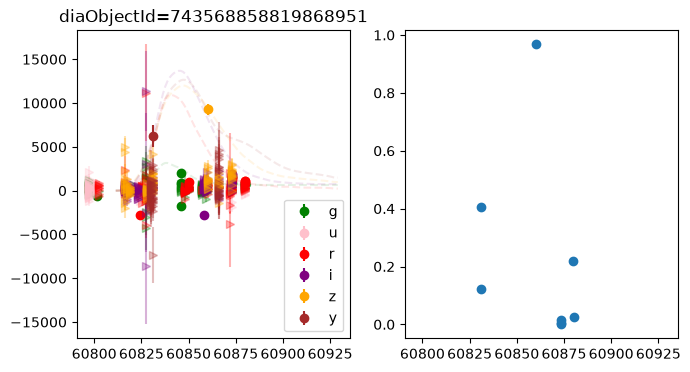

{'x0': 8.782646069473616e-06, 'x1': 0.928660023575853, 'c': 0.1873525336917441, 'z': 0.47435864759988733, 'mwebv': 0.005737510575012076, 't0': 60886.87957580621}
dist,reduced_chi2= 0.25705753320454217 1.4598261704168352


/local/tmp/ipykernel_1732486/1038814261.py:9: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))


In [ ]:
from legacy_survey_cutout import plot_legacy_cutout
cols = ["x0","x1","c","z","mwebv","t0"]
for i in np.random.choice(len(sn),size=np.min([20,len(sn)]),replace=False):
    saltpars_df = result_good.loc[result_good.id==sn.iloc[i]["diaObjectId_dia_object_lc"]]
    saltpars = {}
    for col in cols:
        saltpars[col] = saltpars_df[col].values[0]
    print(saltpars)
    print("dist,reduced_chi2=",sn.iloc[i]["_dist_arcsec"], float(result_good.loc[result_good.id==sn.iloc[i].diaObjectId_dia_object_lc]["reduced_chisq"]))
    plt.figure(figsize=(12,4))
    ax = plt.subplot(1,3,1)
    lc = sn.iloc[i]["diaObjectForcedSource_dia_object_lc"]
    lc = lc[["midpointMjdTai","band","psfDiffFlux","psfDiffFluxErr"]]
    phase = (lc["midpointMjdTai"] - saltpars["t0"])/(1.+saltpars["z"])
    good_phase = (phase > -30) & (phase < 100)
    lc = lc.loc[good_phase]
    lc["mjd"] = lc["midpointMjdTai"]
    lc["flux"] = lc["psfDiffFlux"]
    lc["fluxerr"] = lc["psfDiffFluxErr"]
    lc["snr"] = lc["flux"]/lc["fluxerr"]
    # lc_coadd = nightly_coadd(lc["mjd"],lc["band"],lc["flux"],lc["fluxerr"])
    # lc_coadd["snr"] = lc_coadd["flux"]/lc_coadd["fluxerr"]
    # plot_lc(lc_coadd,saltpars=saltpars)
    plot_lc(lc,saltpars=saltpars)
    plt.title(f"diaObjectId={sn.iloc[i]['diaObjectId_dia_object_lc']}")
    # plt.subplot(1,3,1)
    # lc = sn.iloc[i]["diaSource_dia_object_lc"]
    # lc["mjd"] = lc["midpointMjdTai"]
    # lc["flux"] = lc["psfFlux"]
    # lc["fluxerr"] = lc["psfFluxErr"]
    # lc["snr"] = lc["flux"]/lc["fluxerr"]
    # plot_lc(lc,saltpars=saltpars)
    ax2 = plt.subplot(1,3,2)
    plt.plot(sn.iloc[i]["diaSource_dia_object_lc"]["midpointMjdTai"],sn.iloc[i]["diaSource_dia_object_lc"]["reliability"],'o')
    plt.xlim(ax.get_xlim())
    # ax = plt.subplot(1,3,3)
    # ra = sn.iloc[i]["ra_dia_object_lc"]
    # dec = sn.iloc[i]["dec_dia_object_lc"]
    # img = plot_legacy_cutout(ra, dec, size=115, pixscale=0.262, layer="ls-dr10", fmt="jpg",ax=ax)
    plt.show()

In [105]:
sn.to_parquet(outdir / "final_sample.parquet")